## Cell 1 — Imports

In [1]:
import os
import json
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from pathlib import Path
from IPython.display import display

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report
)

from xgboost import XGBClassifier
import joblib

warnings.filterwarnings("ignore")
print("Libraries loaded successfully.")

Libraries loaded successfully.


## Cell 2 — Project Paths

In [2]:
BASE_DIR       = Path("..")
RAW_DIR        = BASE_DIR / "data" / "raw"
PROCESSED_DIR  = BASE_DIR / "data" / "processed"
MODELS_DIR     = BASE_DIR / "models"
REPORTS_DIR    = BASE_DIR / "reports"

PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
MODELS_DIR.mkdir(parents=True, exist_ok=True)
REPORTS_DIR.mkdir(parents=True, exist_ok=True)

DATASET_PATH = RAW_DIR / "manganese_prospectivity_MP_MH_1km.csv"

if not DATASET_PATH.exists():
    raise FileNotFoundError(f"Dataset not found: {DATASET_PATH.resolve()}")

print("Dataset:", DATASET_PATH.resolve())
print(f"File size: {DATASET_PATH.stat().st_size / (1024**2):.1f} MB")

Dataset: /Users/arpitrajput/Desktop/StudyMaterial/SIH12Sept/mlModel/data/raw/manganese_prospectivity_MP_MH_1km.csv
File size: 274.8 MB


## Cell 3 — Load Dataset

In [3]:
df = pd.read_csv(DATASET_PATH)
print("Shape:", df.shape)
print("\nFirst 3 rows:")
display(df.head(3))

Shape: (622584, 57)

First 3 rows:


,cell_id,latitude,longitude,state,district,tehsil,spatial_block_id,B2_mean,B3_mean,B4_mean,...,LST_c,soil_moisture,resistivity_ohm_m,gravity_anomaly_mgal,label_source,label_confidence,label_year,label_method,label,split
0,MP_0777_0704,22.579878,79.483170,Madhya Pradesh,MP-SynDist-019017,MP-SynTeh-00640058,BLK_0031_0028,0.0610,0.0865,0.0783,...,27.58,0.258,141.3,1.216,not_surveyed,0.0,0,unsurveyed,-1,PREDICT
1,MP_0782_0850,22.624794,80.889908,Madhya Pradesh,MP-SynDist-019021,MP-SynTeh-00650070,BLK_0031_0034,0.1202,0.1265,0.1590,...,28.89,0.146,81.4,5.639,not_surveyed,0.0,0,unsurveyed,-1,PREDICT
2,MP_0852_0677,23.253611,79.223022,Madhya Pradesh,MP-SynDist-021016,MP-SynTeh-00710056,BLK_0034_0027,0.0849,0.1038,0.1165,...,27.67,0.293,188.5,4.003,not_surveyed,0.0,0,unsurveyed,-1,PREDICT


## Cell 4 — Basic EDA

In [4]:
print("Label distribution:")
print(df["label"].value_counts())
print("\n  -1 = unsurveyed (PREDICT set)")
print("   0 = non-prospective")
print("   1 = prospective (manganese deposit likely)")

print("\nSplit distribution:")
print(df["split"].value_counts())

print("\nMissing values (top 10):")
print(df.isnull().sum().sort_values(ascending=False).head(10))

Label distribution:
label
-1    435809
 0    124517
 1     62258
Name: count, dtype: int64

  -1 = unsurveyed (PREDICT set)
   0 = non-prospective
   1 = prospective (manganese deposit likely)

Split distribution:
split
PREDICT       435809
TRAIN         125891
TEST           30929
VALIDATION     29955
Name: count, dtype: int64

Missing values (top 10):
cell_id                            0
TPI                                0
roughness                          0
drainage_density                   0
lithology                          0
host_rock                          0
geomorphology                      0
lineament_density                  0
structural_intersection_density    0
soil_ph                            0
dtype: int64


## Cell 5 — Separate Labelled vs Predict Set

In [5]:
# Only TRAIN / TEST rows have real labels (0 or 1)
labelled_df = df[df["label"] != -1].copy()
predict_df  = df[df["label"] == -1].copy()

print("Labelled rows (TRAIN + TEST):", len(labelled_df))
print("Predict rows  (unsurveyed)   :", len(predict_df))

print("\nLabel distribution in labelled set:")
print(labelled_df["label"].value_counts())

print("\nClass balance (%):")
print((labelled_df["label"].value_counts(normalize=True) * 100).round(2))

Labelled rows (TRAIN + TEST): 186775
Predict rows  (unsurveyed)   : 435809

Label distribution in labelled set:
label
0    124517
1     62258
Name: count, dtype: int64

Class balance (%):
label
0    66.67
1    33.33
Name: proportion, dtype: float64


## Cell 6 — Define Features

In [6]:
# Columns to exclude from features
EXCLUDE = [
    "cell_id", "label", "split",
    "label_source", "label_confidence", "label_year", "label_method",
    "spatial_block_id", "tehsil", "district"   # high-cardinality IDs
]

ALL_FEATURES = [c for c in df.columns if c not in EXCLUDE]

numeric_features     = [c for c in ALL_FEATURES
                         if labelled_df[c].dtype in ["float64","int64","float32","int32"]]
categorical_features = [c for c in ALL_FEATURES
                         if labelled_df[c].dtype == "object"]

print("Total features  :", len(ALL_FEATURES))
print("Numeric         :", len(numeric_features))
print("Categorical     :", len(categorical_features))
print("  →", categorical_features)

Total features  : 47
Numeric         : 43
Categorical     : 0
  → []


## Cell 7 — Train / Test Split  
*(Using the pre-existing `split` column)*

In [7]:
train_df = labelled_df[labelled_df["split"] == "TRAIN"].copy()
test_df  = labelled_df[labelled_df["split"] == "TEST"].copy()

# Fallback: if split column not used, do 80/20 chronological
if len(train_df) == 0:
    print("WARNING: No TRAIN split found — falling back to 80/20.")
    split_idx = int(len(labelled_df) * 0.8)
    train_df  = labelled_df.iloc[:split_idx].copy()
    test_df   = labelled_df.iloc[split_idx:].copy()

print(f"Train rows : {len(train_df)}")
print(f"Test rows  : {len(test_df)}")
print(f"Train label dist:\n{train_df['label'].value_counts()}")

Train rows : 125891
Test rows  : 30929
Train label dist:
label
0    83990
1    41901
Name: count, dtype: int64


## Cell 8 — Prepare X / y

In [8]:
TARGET = "label"

X_train = train_df[ALL_FEATURES].copy()
X_test  = test_df[ALL_FEATURES].copy()
X_pred  = predict_df[ALL_FEATURES].copy()

y_train = train_df[TARGET]
y_test  = test_df[TARGET]

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("X_pred :", X_pred.shape)

X_train: (125891, 47)
X_test : (30929, 47)
X_pred : (435809, 47)


## Cell 9 — Preprocessing Pipeline

In [9]:
numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median"))
])

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

preprocessor = ColumnTransformer([
    ("numeric",     numeric_pipeline,     numeric_features),
    ("categorical", categorical_pipeline, categorical_features)
])

print("Preprocessor built.")

Preprocessor built.


## Cell 10 — Compute Class Weight for Imbalance

In [10]:
n_neg = (y_train == 0).sum()
n_pos = (y_train == 1).sum()
scale_pos_weight = n_neg / n_pos

print(f"Negative (non-prospective) : {n_neg}")
print(f"Positive (prospective)     : {n_pos}")
print(f"scale_pos_weight           : {scale_pos_weight:.2f}")

Negative (non-prospective) : 83990
Positive (prospective)     : 41901
scale_pos_weight           : 2.00


## Cell 11 — Train XGBoost Prospectivity Classifier

In [11]:
model = XGBClassifier(
    n_estimators=400,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="binary:logistic",
    eval_metric="auc",
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    n_jobs=-1
)

pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", model)
])

print("Training prospectivity classifier...")
pipeline.fit(X_train, y_train)
print("Training complete.")

Training prospectivity classifier...


Training complete.


## Cell 12 — Evaluate on Test Set

In [12]:
y_pred      = pipeline.predict(X_test)
y_prob      = pipeline.predict_proba(X_test)[:, 1]

accuracy  = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, zero_division=0)
recall    = recall_score(y_test, y_pred, zero_division=0)
f1        = f1_score(y_test, y_pred, zero_division=0)
roc_auc   = roc_auc_score(y_test, y_prob)

print("PROSPECTIVITY MODEL — TEST RESULTS")
print("=" * 38)
print(f"Accuracy  : {accuracy:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1 Score  : {f1:.4f}")
print(f"ROC-AUC   : {roc_auc:.4f}")
print()
print(classification_report(y_test, y_pred,
      target_names=["Non-Prospective", "Prospective"]))

PROSPECTIVITY MODEL — TEST RESULTS
Accuracy  : 0.8727
Precision : 0.7724
Recall    : 0.8834
F1 Score  : 0.8242
ROC-AUC   : 0.9510

                 precision    recall  f1-score   support

Non-Prospective       0.94      0.87      0.90     20487
    Prospective       0.77      0.88      0.82     10442

       accuracy                           0.87     30929
      macro avg       0.85      0.88      0.86     30929
   weighted avg       0.88      0.87      0.87     30929



## Cell 13 — Confusion Matrix

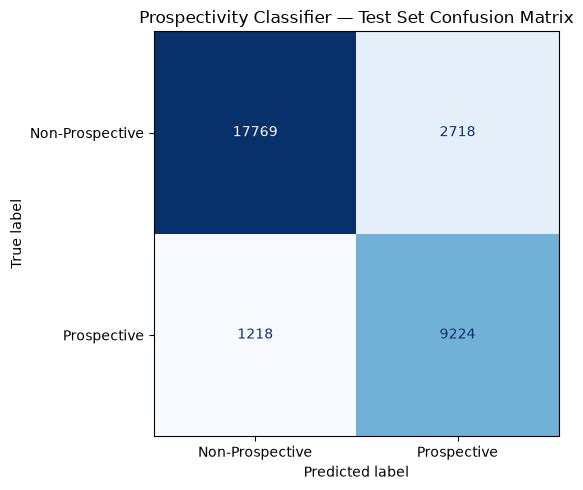

Saved confusion matrix.


In [13]:
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=["Non-Prospective", "Prospective"])
fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(ax=ax, colorbar=False, cmap="Blues")
ax.set_title("Prospectivity Classifier — Test Set Confusion Matrix")
plt.tight_layout()
plt.savefig(REPORTS_DIR / "prospectivity_confusion_matrix.png", dpi=150)
plt.show()
print("Saved confusion matrix.")

## Cell 14 — Feature Importance (Top 20)

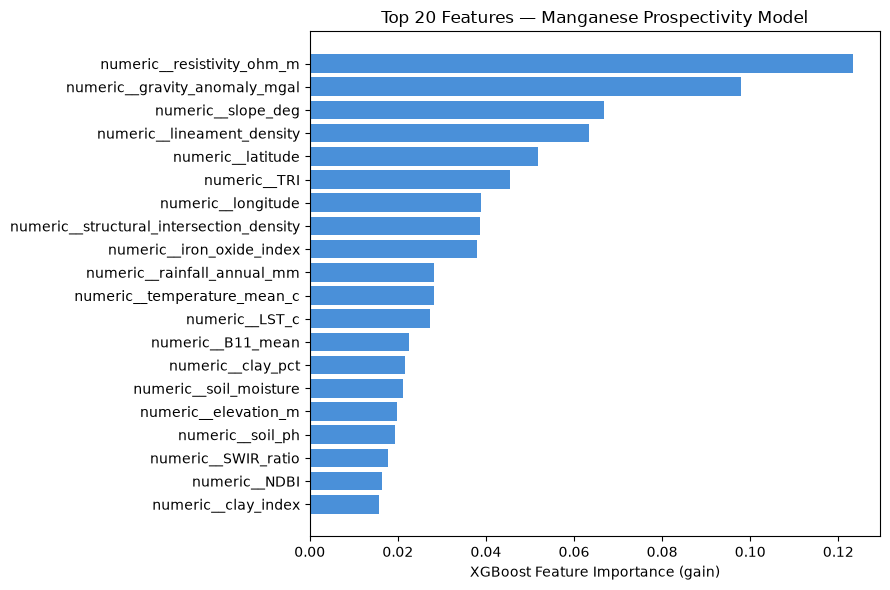

Saved feature importance plot.


In [14]:
fitted_preprocessor = pipeline.named_steps["preprocessor"]
fitted_model        = pipeline.named_steps["model"]

feature_names = fitted_preprocessor.get_feature_names_out()
importances   = fitted_model.feature_importances_

fi_df = (pd.DataFrame({"feature": feature_names, "importance": importances})
           .sort_values("importance", ascending=False)
           .head(20))

fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(fi_df["feature"][::-1], fi_df["importance"][::-1], color="#4A90D9")
ax.set_xlabel("XGBoost Feature Importance (gain)")
ax.set_title("Top 20 Features — Manganese Prospectivity Model")
plt.tight_layout()
plt.savefig(REPORTS_DIR / "prospectivity_feature_importance.png", dpi=150)
plt.show()
print("Saved feature importance plot.")

## Cell 15 — Predict on Unsurveyed Cells

In [15]:
predict_proba = pipeline.predict_proba(X_pred)[:, 1]
predict_label = pipeline.predict(X_pred)

results_df = predict_df[["cell_id", "latitude", "longitude", "state"]].copy()
results_df["prospectivity_prob"]  = predict_proba.round(4)
results_df["predicted_label"]     = predict_label
results_df["prospectivity_level"] = pd.cut(
    predict_proba,
    bins=[0, 0.3, 0.6, 0.8, 1.0],
    labels=["LOW", "MEDIUM", "HIGH", "VERY HIGH"]
)

results_df = results_df.sort_values("prospectivity_prob", ascending=False)

print(f"Total unsurveyed cells predicted: {len(results_df)}")
print("\nProspectivity level distribution:")
print(results_df["prospectivity_level"].value_counts())
print("\nTop 10 most prospective cells:")
display(results_df.head(10))

Total unsurveyed cells predicted: 435809

Prospectivity level distribution:
prospectivity_level
LOW          315269
VERY HIGH     49714
MEDIUM        43360
HIGH          27466
Name: count, dtype: int64

Top 10 most prospective cells:


,cell_id,latitude,longitude,state,prospectivity_prob,predicted_label,prospectivity_level
393261,MP_1155_0564,25.975494,78.134247,Madhya Pradesh,0.9999,1,VERY HIGH
337258,MP_1153_0565,25.957527,78.143883,Madhya Pradesh,0.9999,1,VERY HIGH
18749,MP_1161_0560,26.029392,78.095703,Madhya Pradesh,0.9999,1,VERY HIGH
320115,MP_1156_0563,25.984478,78.124611,Madhya Pradesh,0.9999,1,VERY HIGH
206421,MP_0805_0558,22.831406,78.076431,Madhya Pradesh,0.9999,1,VERY HIGH
565525,MP_0804_0555,22.822422,78.047531,Madhya Pradesh,0.9999,1,VERY HIGH
13748,MP_0807_0556,22.849371,78.057159,Madhya Pradesh,0.9999,1,VERY HIGH
567493,MP_1175_0568,26.155157,78.172783,Madhya Pradesh,0.9999,1,VERY HIGH
309294,MP_0804_0556,22.822422,78.057159,Madhya Pradesh,0.9999,1,VERY HIGH
507968,MP_1154_0564,25.966511,78.134247,Madhya Pradesh,0.9999,1,VERY HIGH


## Cell 16 — Save Predictions CSV

In [16]:
out_path = PROCESSED_DIR / "prospectivity_predictions.csv"
results_df.to_csv(out_path, index=False)
print(f"Predictions saved to: {out_path.resolve()}")
print(f"Total rows: {len(results_df)}")

Predictions saved to: /Users/arpitrajput/Desktop/StudyMaterial/SIH12Sept/mlModel/data/processed/prospectivity_predictions.csv
Total rows: 435809


## Cell 17 — Save Model

In [17]:
joblib.dump(pipeline, MODELS_DIR / "prospectivity_classifier.joblib")
print("Model saved:", (MODELS_DIR / 'prospectivity_classifier.joblib').resolve())

Model saved: /Users/arpitrajput/Desktop/StudyMaterial/SIH12Sept/mlModel/models/prospectivity_classifier.joblib


## Cell 18 — Save Metrics

In [18]:
metrics = {
    "model"     : "XGBClassifier",
    "dataset"   : DATASET_PATH.name,
    "train_rows": int(len(train_df)),
    "test_rows" : int(len(test_df)),
    "accuracy"  : round(float(accuracy),  4),
    "precision" : round(float(precision), 4),
    "recall"    : round(float(recall),    4),
    "f1"        : round(float(f1),        4),
    "roc_auc"   : round(float(roc_auc),   4),
}

with open(REPORTS_DIR / "prospectivity_metrics.json", "w") as f:
    json.dump(metrics, f, indent=4)

print("Metrics saved.")
print(json.dumps(metrics, indent=2))

Metrics saved.
{
  "model": "XGBClassifier",
  "dataset": "manganese_prospectivity_MP_MH_1km.csv",
  "train_rows": 125891,
  "test_rows": 30929,
  "accuracy": 0.8727,
  "precision": 0.7724,
  "recall": 0.8834,
  "f1": 0.8242,
  "roc_auc": 0.951
}


## Cell 19 — Summary

In [19]:
print("=" * 50)
print("MANGANESE PROSPECTIVITY MODEL — COMPLETE")
print("=" * 50)
print(f"Dataset        : {DATASET_PATH.name}")
print(f"Total records  : {len(df):,}")
print(f"Training rows  : {len(train_df):,}")
print(f"Test rows      : {len(test_df):,}")
print(f"Unsurveyed pred: {len(predict_df):,}")
print()
print("TEST METRICS")
print(f"  ROC-AUC   : {roc_auc:.4f}")
print(f"  F1 Score  : {f1:.4f}")
print(f"  Recall    : {recall:.4f}")
print(f"  Precision : {precision:.4f}")
print()
print("OUTPUTS")
print(f"  Model     : models/prospectivity_classifier.joblib")
print(f"  Pred CSV  : data/processed/prospectivity_predictions.csv")
print(f"  Metrics   : reports/prospectivity_metrics.json")

MANGANESE PROSPECTIVITY MODEL — COMPLETE
Dataset        : manganese_prospectivity_MP_MH_1km.csv
Total records  : 622,584
Training rows  : 125,891
Test rows      : 30,929
Unsurveyed pred: 435,809

TEST METRICS
  ROC-AUC   : 0.9510
  F1 Score  : 0.8242
  Recall    : 0.8834
  Precision : 0.7724

OUTPUTS
  Model     : models/prospectivity_classifier.joblib
  Pred CSV  : data/processed/prospectivity_predictions.csv
  Metrics   : reports/prospectivity_metrics.json
